In [1]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

import rasterio

In [2]:
S2_ROOT = Path("data/raw/BigEarthNet-S2")
S1_ROOT = Path("/path/to/BigEarthNet-S1")

print("S2 exists:", S2_ROOT.exists())
print("S1 exists:", S1_ROOT.exists())

S2 exists: True
S1 exists: False


In [3]:
def show_tree(root, max_items=30):
    for i, p in enumerate(root.rglob("*")):
        if i >= max_items:
            break
        print(p.relative_to(root))

show_tree(S2_ROOT, 40)

S2B_MSIL2A_20171015T104009_N9999_R008_T31UGS
S2B_MSIL2A_20171112T114339_N9999_R123_T29UPU
S2A_MSIL2A_20180318T093031_N9999_R136_T35UMB
S2B_MSIL2A_20180201T093219_N9999_R136_T34TEP
S2B_MSIL2A_20170716T093039_N9999_R136_T36VVR
S2A_MSIL2A_20171002T112111_N9999_R037_T29SNB
S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK
S2B_MSIL2A_20180204T094159_N9999_R036_T35VNH
S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU
S2B_MSIL2A_20180421T100029_N9999_R122_T33UXQ
S2B_MSIL2A_20180422T093029_N9999_R136_T34TEQ
S2B_MSIL2A_20180502T093039_N9999_R136_T34TEP
S2B_MSIL2A_20170924T093019_N9999_R136_T35UMB
S2A_MSIL2A_20171015T095031_N9999_R079_T33UXP
S2A_MSIL2A_20180225T114351_N9999_R123_T29UPU
S2A_MSIL2A_20180430T094031_N9999_R036_T34TCR
S2A_MSIL2A_20180509T101031_N9999_R022_T34VDR
S2A_MSIL2A_20180219T094031_N9999_R036_T35WPP
S2B_MSIL2A_20170930T095019_N9999_R079_T34UEG
S2A_MSIL2A_20171002T094031_N9999_R036_T34TCR
S2A_MSIL2A_20180507T093041_N9999_R136_T35UMA
S2A_MSIL2A_20170613T101031_N9999_R022_T34VER
S2B_MSIL2A

In [5]:
s2_patch_dirs = [
    p for p in S2_ROOT.rglob("*")
    if p.is_dir() and list(p.glob("*.tif"))
]

print("S2 patch folders found:", len(s2_patch_dirs))

s2_patch = random.choice(s2_patch_dirs)
print("Selected patch:", s2_patch)
print("Files:", sorted(f.name for f in s2_patch.glob("*.tif")))

S2 patch folders found: 549488
Selected patch: data/raw/BigEarthNet-S2/S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ/S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08
Files: ['S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B01.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B02.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B03.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B04.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B05.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B06.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B07.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B08.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B09.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B11.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B12.tif', 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B8A.tif']


In [6]:
def read_tif(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32), src.profile

def find_band(patch_dir, band):
    matches = list(patch_dir.glob(f"*_{band}.tif")) + list(patch_dir.glob(f"*{band}.tif"))
    if not matches:
        raise FileNotFoundError(f"Band {band} not found in {patch_dir}")
    return matches[0]

def normalize_percentile(x, p_low=2, p_high=98):
    valid = x[np.isfinite(x)]
    lo, hi = np.percentile(valid, [p_low, p_high])
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

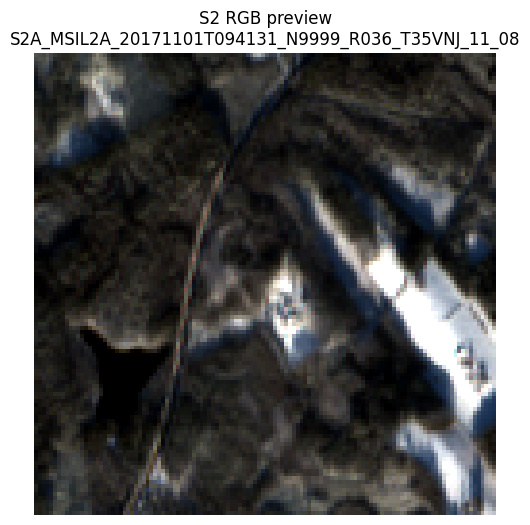

In [7]:
# Sentinel-2 RGB:
# B04 = red
# B03 = green
# B02 = blue

r, _ = read_tif(find_band(s2_patch, "B04"))
g, _ = read_tif(find_band(s2_patch, "B03"))
b, _ = read_tif(find_band(s2_patch, "B02"))

rgb = np.dstack([
    normalize_percentile(r),
    normalize_percentile(g),
    normalize_percentile(b),
])

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"S2 RGB preview\n{s2_patch.name}")
plt.axis("off")
plt.show()

In [8]:
for tif in sorted(s2_patch.glob("*.tif")):
    arr, profile = read_tif(tif)
    print(
        tif.name,
        "shape:", arr.shape,
        "dtype:", profile["dtype"],
        "min:", float(np.nanmin(arr)),
        "max:", float(np.nanmax(arr))
    )

S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B01.tif shape: (20, 20) dtype: uint16 min: 80.0 max: 9115.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B02.tif shape: (120, 120) dtype: uint16 min: 1.0 max: 11416.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B03.tif shape: (120, 120) dtype: uint16 min: 1.0 max: 10944.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B04.tif shape: (120, 120) dtype: uint16 min: 1.0 max: 11592.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B05.tif shape: (60, 60) dtype: uint16 min: 1.0 max: 11415.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B06.tif shape: (60, 60) dtype: uint16 min: 1.0 max: 11051.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B07.tif shape: (60, 60) dtype: uint16 min: 1.0 max: 10723.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B08.tif shape: (120, 120) dtype: uint16 min: 1.0 max: 12216.0
S2A_MSIL2A_20171101T094131_N9999_R036_T35VNJ_11_08_B09.tif shape: (20, 20) dtype: uint16 min: 435.0 max:

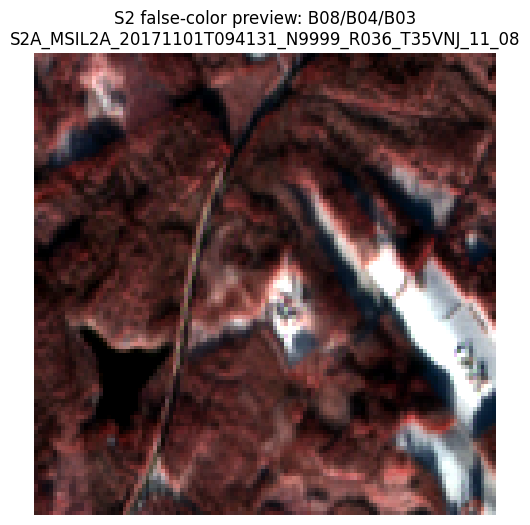

In [9]:
# Common false-color composite:
# B08 = near infrared
# B04 = red
# B03 = green

nir, _ = read_tif(find_band(s2_patch, "B08"))
red, _ = read_tif(find_band(s2_patch, "B04"))
green, _ = read_tif(find_band(s2_patch, "B03"))

false_color = np.dstack([
    normalize_percentile(nir),
    normalize_percentile(red),
    normalize_percentile(green),
])

plt.figure(figsize=(6, 6))
plt.imshow(false_color)
plt.title(f"S2 false-color preview: B08/B04/B03\n{s2_patch.name}")
plt.axis("off")
plt.show()

In [12]:
from pathlib import Path
from PIL import Image
from tqdm import tqdm

RGB_OUTPUT_ROOT = Path("./data/derived/BigEarthNet-RGB")

RGB_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(RGB_OUTPUT_ROOT)

data/derived/BigEarthNet-RGB


In [13]:
def build_rgb_image(patch_dir):
    r, _ = read_tif(find_band(patch_dir, "B04"))
    g, _ = read_tif(find_band(patch_dir, "B03"))
    b, _ = read_tif(find_band(patch_dir, "B02"))

    rgb = np.dstack([
        normalize_percentile(r),
        normalize_percentile(g),
        normalize_percentile(b),
    ])

    rgb_uint8 = (rgb * 255).astype(np.uint8)

    return rgb_uint8

In [ ]:
rgb_dataset_length = 0

for patch_dir in tqdm(s2_patch_dirs):
    
    try:
        rgb = build_rgb_image(patch_dir)

        output_name = patch_dir.name + ".png"
        output_path = RGB_OUTPUT_ROOT / output_name

        Image.fromarray(rgb).save(output_path)

        rgb_dataset_length += 1

    except Exception as e:
        print(f"Skipping {patch_dir.name}: {e}")

100%|██████████| 549488/549488 [1:10:50<00:00, 129.29it/s]


In [15]:
tile_dirs = [
    p for p in S2_ROOT.iterdir()
    if p.is_dir()
]

print("Number of tiles:", len(tile_dirs))

Number of tiles: 115


In [16]:
tile_patch_counts = {}

for tile in tile_dirs:

    patch_count = len([
        p for p in tile.iterdir()
        if p.is_dir()
    ])

    tile_patch_counts[tile.name] = patch_count

print("Computed patch counts for all tiles.")

Computed patch counts for all tiles.


In [17]:
for tile_name, count in list(tile_patch_counts.items())[:10]:
    print(tile_name, "->", count, "patches")

S2B_MSIL2A_20171015T104009_N9999_R008_T31UGS -> 729 patches
S2B_MSIL2A_20171112T114339_N9999_R123_T29UPU -> 8183 patches
S2A_MSIL2A_20180318T093031_N9999_R136_T35UMB -> 5032 patches
S2B_MSIL2A_20180201T093219_N9999_R136_T34TEP -> 8171 patches
S2B_MSIL2A_20170716T093039_N9999_R136_T36VVR -> 261 patches
S2A_MSIL2A_20171002T112111_N9999_R037_T29SNB -> 8165 patches
S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK -> 7999 patches
S2B_MSIL2A_20180204T094159_N9999_R036_T35VNH -> 5557 patches
S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU -> 6032 patches
S2B_MSIL2A_20180421T100029_N9999_R122_T33UXQ -> 341 patches


In [18]:
counts = np.array(list(tile_patch_counts.values()))

print("Number of tiles:", len(counts))
print("Total patches:", counts.sum())

print("Min patches in a tile:", counts.min())
print("Max patches in a tile:", counts.max())

print("Average patches per tile:", counts.mean())
print("Median patches per tile:", np.median(counts))

Number of tiles: 115
Total patches: 549488
Min patches in a tile: 95
Max patches in a tile: 8269
Average patches per tile: 4778.156521739131
Median patches per tile: 4943.0


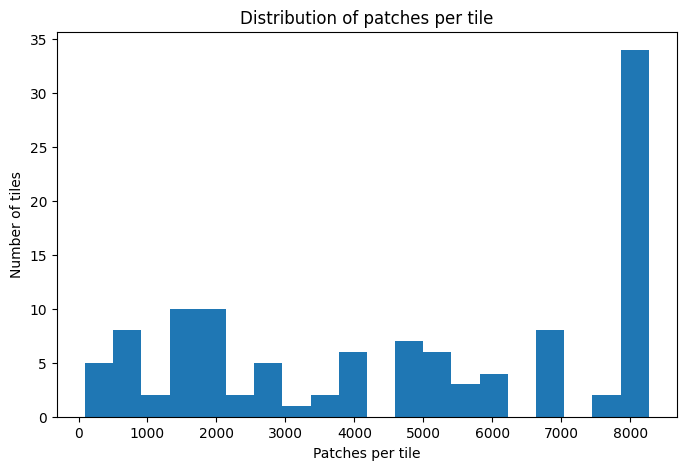

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(counts, bins=20)

plt.xlabel("Patches per tile")
plt.ylabel("Number of tiles")
plt.title("Distribution of patches per tile")

plt.show()

In [20]:
sorted_tiles = sorted(
    tile_patch_counts.items(),
    key=lambda x: x[1]
)

print("Smallest tiles:")
for name, count in sorted_tiles[:5]:
    print(name, "->", count)

print("\nLargest tiles:")
for name, count in sorted_tiles[-5:]:
    print(name, "->", count)

Smallest tiles:
S2A_MSIL2A_20171210T101411_N9999_R022_T33UWP -> 95
S2B_MSIL2A_20170716T093039_N9999_R136_T36VVR -> 261
S2B_MSIL2A_20180421T100029_N9999_R122_T33UXQ -> 341
S2B_MSIL2A_20170831T095029_N9999_R079_T33UXQ -> 341
S2A_MSIL2A_20170717T113321_N9999_R080_T29UPA -> 370

Largest tiles:
S2B_MSIL2A_20180502T093039_N9999_R136_T34TEP -> 8248
S2B_MSIL2A_20180525T094029_N9999_R036_T35VNK -> 8258
S2A_MSIL2A_20180205T100211_N9999_R122_T35VLJ -> 8258
S2B_MSIL2A_20180204T094159_N9999_R036_T35VNJ -> 8269
S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ -> 8269


In [21]:
EXPECTED = 549_488

actual = counts.sum()

print("Expected:", EXPECTED)
print("Actual:", actual)

print("Match:", EXPECTED == actual)

Expected: 549488
Actual: 549488
Match: True
